### 1. Importing libraries

In [1]:
# Install dependencies as needed:
!pip install -q prophet xgboost scikit-learn plotly
!pip install -q plotly kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.2 MB/s eta 0:00:00


In [2]:
# 'os' module provides functions for interacting with the operating system
import os

# 'Numpy' is used for mathematical operations on large, multi-dimensional arrays and matrices
import numpy as np

# 'Pandas' is used for data manipulation and analysis
import pandas as pd

# 'Matplotlib' is a data visualization library for 2D and 3D plots, built on numpy
from matplotlib import pyplot as plt
%matplotlib inline

# 'Seaborn' is based on matplotlib; used for plotting statistical graphics
import seaborn as sns

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

### 2. Importing and Exploration of the dataset

In [8]:
file_path = "monthly_revenue.csv"

df_original = pd.read_csv("monthly_revenue.csv")

In [9]:
# showing the first 5 rows of the dataset:
df_original.head()

,year,month,quarter,orders,revenue_usd,avg_order_value,avg_discount_pct,return_rate,unique_customers,new_customers
0,2020,1,Q1,266,35415.25,133.14,5.68,0.0,261,100
1,2020,2,Q1,268,34304.78,128.00,6.06,0.0,263,93
2,2020,3,Q1,258,32642.23,126.52,5.21,0.0,254,81
3,2020,4,Q2,281,34865.39,124.08,5.27,0.0,275,99
4,2020,5,Q2,286,38625.73,135.06,5.84,0.0,282,113


In [10]:
# checking the dimensions of the dataset:
df_original.shape

(75, 10)

In [11]:
# checking the info
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              75 non-null     int64  
 1   month             75 non-null     int64  
 2   quarter           75 non-null     object 
 3   orders            75 non-null     int64  
 4   revenue_usd       75 non-null     float64
 5   avg_order_value   75 non-null     float64
 6   avg_discount_pct  75 non-null     float64
 7   return_rate       75 non-null     float64
 8   unique_customers  75 non-null     int64  
 9   new_customers     75 non-null     int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 6.0+ KB


### 3. Converting the data types

In [12]:
df = df_original.copy()

# year, month and quarter columns
df['month'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str))
df['year'] = df['month'].dt.year
df['quarter'] = df['month'].dt.quarter

In [13]:
# Checking the datatypes again:
df.dtypes

,0
year,int32
month,datetime64[ns]
quarter,int32
orders,int64
revenue_usd,float64
avg_order_value,float64
avg_discount_pct,float64
return_rate,float64
unique_customers,int64
new_customers,int64


### 4. Summary statistics of the data

In [14]:
# Summary Statistics for Numerical data:
df.describe()

,year,month,quarter,orders,revenue_usd,avg_order_value,avg_discount_pct,return_rate,unique_customers,new_customers
count,75.000000,75,75.000000,75.000000,75.000000,75.000000,75.000000,75.0,75.000000,75.000000
mean,2022.640000,2023-01-30 22:43:12,2.440000,273.293333,34468.353333,126.048533,5.632933,0.0,268.400000,97.120000
min,2020.000000,2020-01-01 00:00:00,1.000000,237.000000,25922.180000,109.380000,4.340000,0.0,236.000000,76.000000
25%,2021.000000,2021-07-16 12:00:00,1.000000,262.000000,31878.580000,119.905000,5.220000,0.0,256.000000,93.000000
50%,2023.000000,2023-02-01 00:00:00,2.000000,269.000000,34020.340000,125.540000,5.590000,0.0,263.000000,97.000000
75%,2024.000000,2024-08-16 12:00:00,3.000000,285.500000,36749.420000,130.955000,6.185000,0.0,281.000000,102.000000
max,2026.000000,2026-03-01 00:00:00,4.000000,316.000000,44793.180000,153.290000,7.060000,0.0,309.000000,122.000000
std,1.820603,NaN,1.141834,17.005383,3436.609880,8.841044,0.598473,0.0,16.604298,9.366357


In [15]:
# Summary Statistics for Categorical data:
df.describe(exclude=[np.number])

,month
count,75
mean,2023-01-30 22:43:12
min,2020-01-01 00:00:00
25%,2021-07-16 12:00:00
50%,2023-02-01 00:00:00
75%,2024-08-16 12:00:00
max,2026-03-01 00:00:00


### 5. Missing values

In [16]:
# Detect null columns
df.isnull().sum()

,0
year,0
month,0
quarter,0
orders,0
revenue_usd,0
avg_order_value,0
avg_discount_pct,0
return_rate,0
unique_customers,0
new_customers,0


In [17]:
# Detect zero columns
zero_cols = [col for col in df.columns if (df[col] == 0).all()]
print(f"All-zero columns found: {zero_cols}")

df = df.drop(columns=zero_cols)
print(f"Dropped: {zero_cols}")
print(f"Remaining columns: {df.columns.tolist()}")

All-zero columns found: ['return_rate']
Dropped: ['return_rate']
Remaining columns: ['year', 'month', 'quarter', 'orders', 'revenue_usd', 'avg_order_value', 'avg_discount_pct', 'unique_customers', 'new_customers']


### 6. Duplicates

In [18]:
df.duplicated().sum()

np.int64(0)

There are no duplicate rows in the data

### 7. Outliers Detection

To check for the presence of outliers, we plot Boxplot.

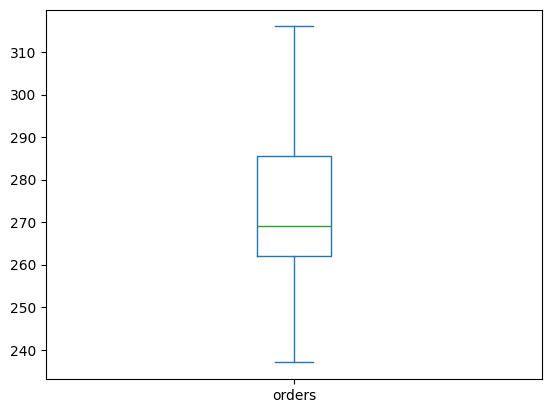

In [19]:
# for orders
df['orders'].plot(kind='box')
plt.show()

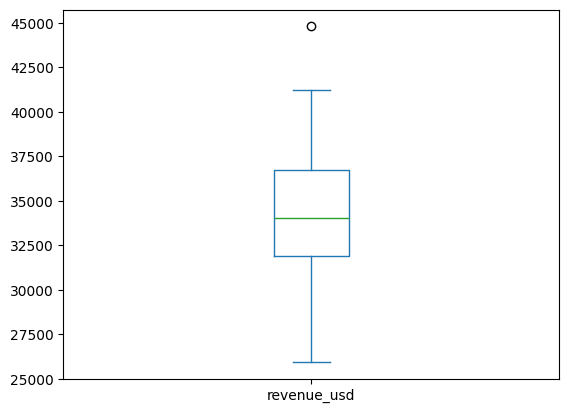

In [20]:
# for revenue_usd
df['revenue_usd'].plot(kind='box')
plt.show()

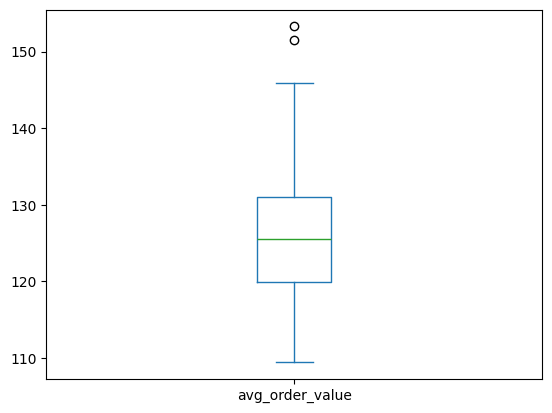

In [21]:
# for avg_order_value
df['avg_order_value'].plot(kind='box')
plt.show()

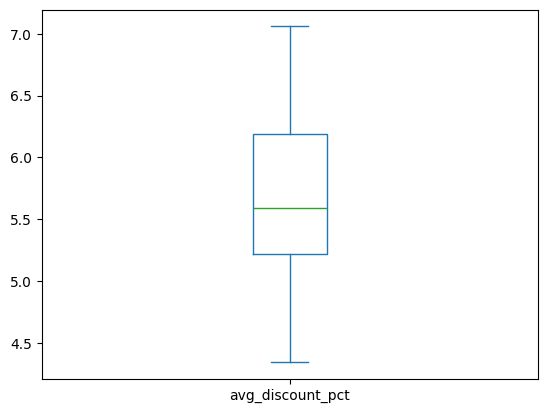

In [22]:
# for avg_discount_pct
df['avg_discount_pct'].plot(kind='box')
plt.show()

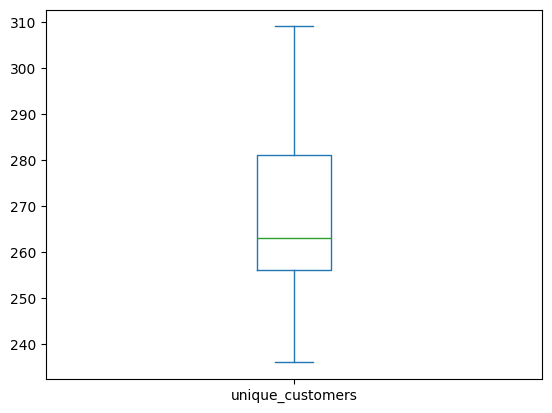

In [23]:
# for unique_customers
df['unique_customers'].plot(kind='box')
plt.show()

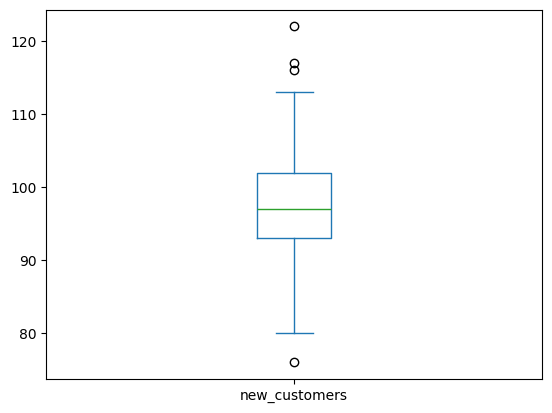

In [24]:
# for new_customers
df['new_customers'].plot(kind='box')
plt.show()

We can see there is presence of outlier in revenue_usd, avg_order_value and new_customers columns

### 8. Outliers Treatment using IQR Method
All the values below Q1 - 1.5IQR and values above Q3 + 1.5IQR are outliers and can be removed.

In [25]:
# for revenue_usd
Q1 = df["revenue_usd"].quantile(0.25)
Q3 = df["revenue_usd"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["is_outlier"] = (df["revenue_usd"] < lower) | (df["revenue_usd"] > upper)
print(df[df["is_outlier"]][["year", "month", "revenue_usd"]])
df.drop(columns = ['is_outlier'], inplace=True)

    year      month  revenue_usd
72  2026 2026-01-01     44793.18


In [26]:
## Store the clean data:
df = df[(df.revenue_usd > lower) & (df.revenue_usd < upper)]
df.shape

(74, 9)

In [27]:
# for avg_order_value
Q1 = df["avg_order_value"].quantile(0.25)
Q3 = df["avg_order_value"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["is_outlier"] = (df["avg_order_value"] < lower) | (df["avg_order_value"] > upper)
print(df[df["is_outlier"]][["year", "month", "avg_order_value"]])
df.drop(columns = ['is_outlier'], inplace=True)

    year      month  avg_order_value
66  2025 2025-07-01           153.29
73  2026 2026-02-01           151.53


In [28]:
## Store the clean data:
df = df[(df.avg_order_value > lower) & (df.avg_order_value < upper)]
df.shape

(72, 9)

In [29]:
# for new_customers
Q1 = df["new_customers"].quantile(0.25)
Q3 = df["new_customers"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["is_outlier"] = (df["new_customers"] < lower) | (df["new_customers"] > upper)
print(df[df["is_outlier"]][["year", "month", "new_customers"]])
df.drop(columns = ['is_outlier'], inplace=True)

    year      month  new_customers
23  2021 2021-12-01            122
33  2022 2022-10-01            117
42  2023 2023-07-01             76


In [30]:
## Store the clean data:
df = df[(df.new_customers > lower) & (df.new_customers < upper)]
df.shape

(69, 9)

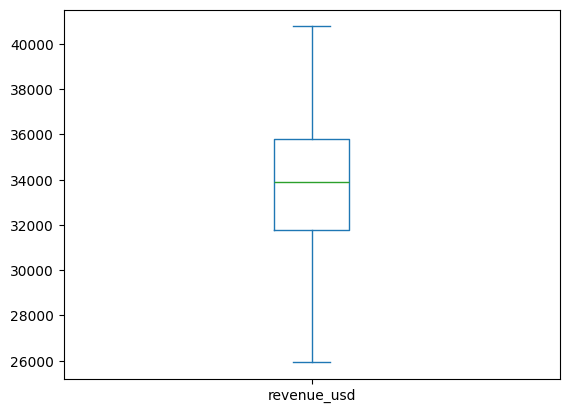

In [31]:
# recheck revenue_usd for outliers
df['revenue_usd'].plot(kind='box')
plt.show()

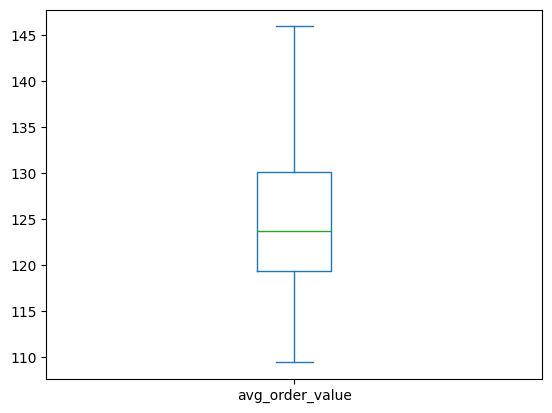

In [32]:
# recheck avg_order_value for outliers
df['avg_order_value'].plot(kind='box')
plt.show()

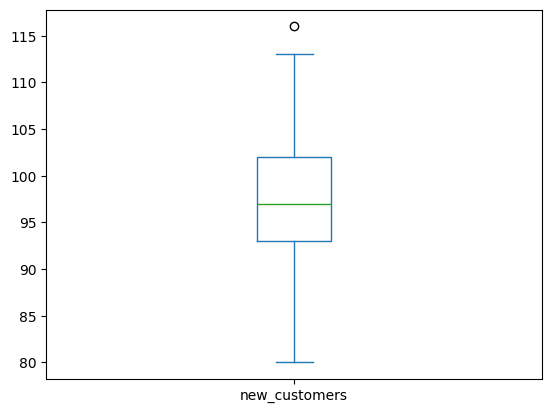

In [33]:
# recheck new_customers for outliers
df['new_customers'].plot(kind='box')
plt.show()

### 9. Scaling the Numerical Features

There are two ways to scale the data:

1) Standardization (Z-Score)
2) Normalization: Min Max Scalar

We are going to use Standardization (Z-Score) to scale our data.

In [34]:
# for orders
avg_orders = df['orders'].mean()
std_orders = df['orders'].std()

# for avg_order_value
avg_avg_order_value = df['avg_order_value'].mean()
std_avg_order_value = df['avg_order_value'].std()

# for avg_discount_pct
avg_avg_discount_pct = df['avg_discount_pct'].mean()
std_avg_discount_pct = df['avg_discount_pct'].std()

# for unique_customers
avg_unique_customers = df['unique_customers'].mean()
std_unique_customers = df['unique_customers'].std()

# for new_customers
avg_new_customers = df['new_customers'].mean()
std_new_customers = df['new_customers'].std()

# normalizing using formula (x-avg)/std
df['orders'] = (df['orders'] - avg_orders) / std_orders
df['avg_order_value'] = (df['avg_order_value'] - avg_avg_order_value) / std_avg_order_value
df['avg_discount_pct'] = (df['avg_discount_pct'] - avg_avg_discount_pct) / std_avg_discount_pct
df['unique_customers'] = (df['unique_customers'] - avg_unique_customers)/ std_unique_customers
df['new_customers'] = (df['new_customers'] - avg_new_customers)/ std_new_customers

df.head()

,year,month,quarter,orders,revenue_usd,avg_order_value,avg_discount_pct,unique_customers,new_customers
0,2020,2020-01-01,1,-0.395043,35415.25,1.060478,0.059644,-0.408491,0.364754
1,2020,2020-02-01,1,-0.268262,34304.78,0.394268,0.700572,-0.278901,-0.458500
2,2020,2020-03-01,1,-0.902168,32642.23,0.202440,-0.733082,-0.862057,-1.869792
3,2020,2020-04-01,2,0.555816,34865.39,-0.113815,-0.631883,0.498641,0.247147
4,2020,2020-05-01,2,0.872769,38625.73,1.309335,0.329508,0.952207,1.893654


### 10. Encoding the Categorical Features

There are two ways to encode the categorical data into dummy variables. Using:

1) pd.get_dummies
2) sklearn's in-built function of OneHotEncoder and LabelEncoder

We are going to use LabelEncoder to encode our data.

In [35]:
# year, month and quarter columns
df['year_enc'] = LabelEncoder().fit_transform(df['year'].fillna('Unknown'))
df['month_enc'] = LabelEncoder().fit_transform(df['month'].fillna('Unknown'))
df['quarter_enc'] = LabelEncoder().fit_transform(df['quarter'].fillna('Unknown'))
df.head()

,year,month,quarter,orders,revenue_usd,avg_order_value,avg_discount_pct,unique_customers,new_customers,year_enc,month_enc,quarter_enc
0,2020,2020-01-01,1,-0.395043,35415.25,1.060478,0.059644,-0.408491,0.364754,0,0,0
1,2020,2020-02-01,1,-0.268262,34304.78,0.394268,0.700572,-0.278901,-0.458500,0,1,0
2,2020,2020-03-01,1,-0.902168,32642.23,0.202440,-0.733082,-0.862057,-1.869792,0,2,0
3,2020,2020-04-01,2,0.555816,34865.39,-0.113815,-0.631883,0.498641,0.247147,0,3,1
4,2020,2020-05-01,2,0.872769,38625.73,1.309335,0.329508,0.952207,1.893654,0,4,1


### 5. Exploratory Data Analysis (EDA)

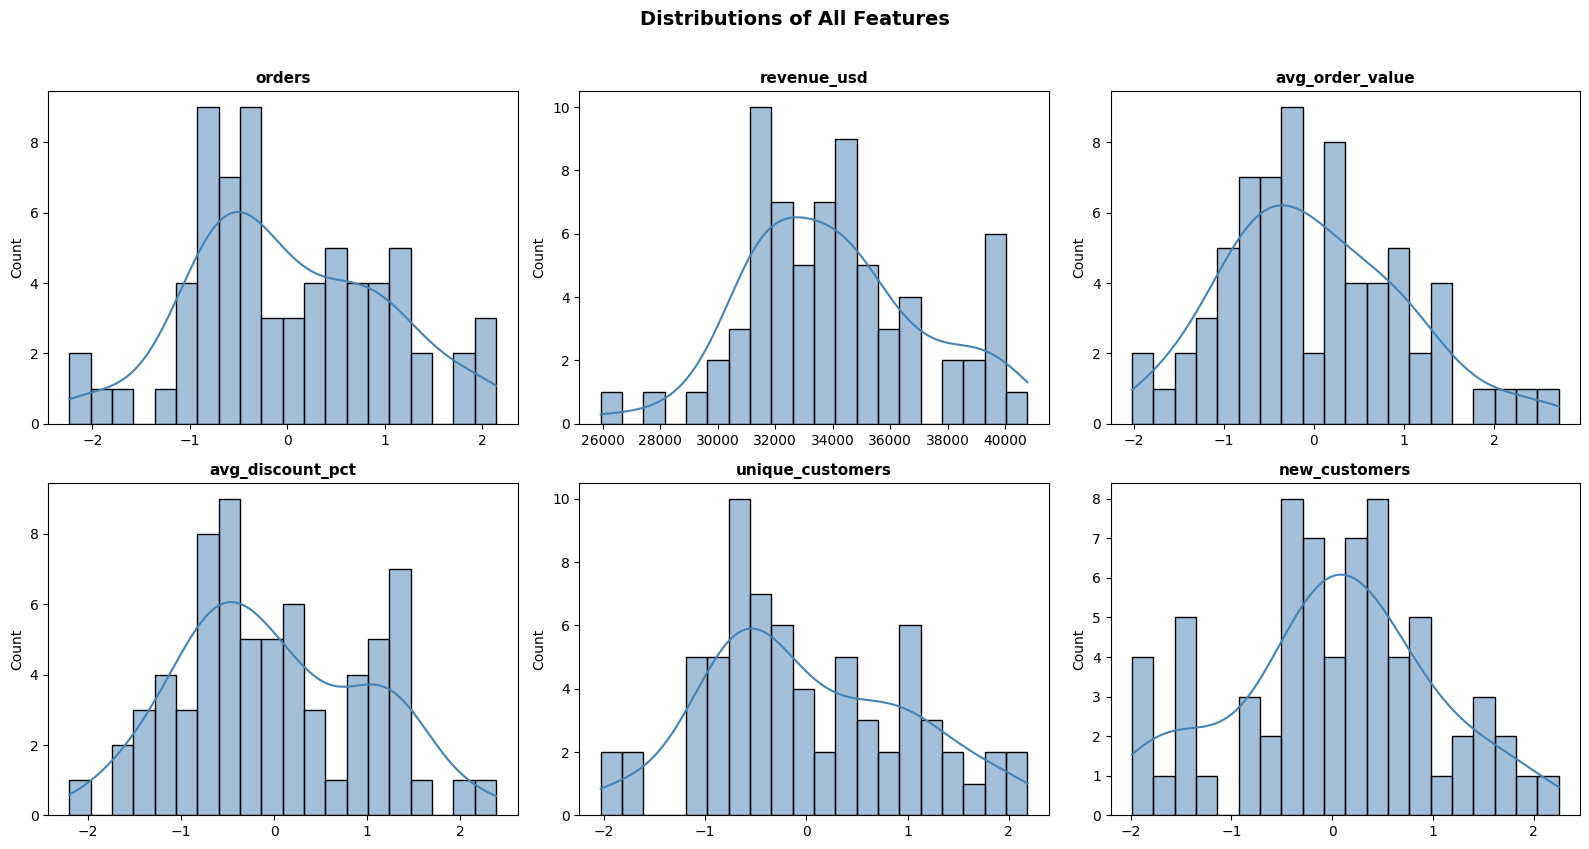

In [36]:
## Distribution and Stats
# Define numeric columns
numeric_cols = [
    "orders", "revenue_usd", "avg_order_value", "avg_discount_pct", "unique_customers", "new_customers"
]

# Histogram + KDE for each column
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue", bins=20)
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of All Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [37]:
## Skewness & Kurtosis table
skew_kurt = pd.DataFrame({
    "Skewness": df[numeric_cols].skew().round(3),
    "Kurtosis": df[numeric_cols].kurt().round(3)
})

# Flag high skewness (>1 or <-1)
def flag(val, threshold=1):
    return "High" if abs(val) > threshold else "Normal"

skew_kurt["Skew Flag"]  = skew_kurt["Skewness"].apply(flag)
skew_kurt["Kurt Flag"]  = skew_kurt["Kurtosis"].apply(lambda x: flag(x, 3))

display(skew_kurt)

,Skewness,Kurtosis,Skew Flag,Kurt Flag
orders,0.167,-0.344,Normal,Normal
revenue_usd,0.255,-0.101,Normal,Normal
avg_order_value,0.445,0.043,Normal,Normal
avg_discount_pct,0.243,-0.583,Normal,Normal
unique_customers,0.282,-0.533,Normal,Normal
new_customers,-0.117,-0.277,Normal,Normal


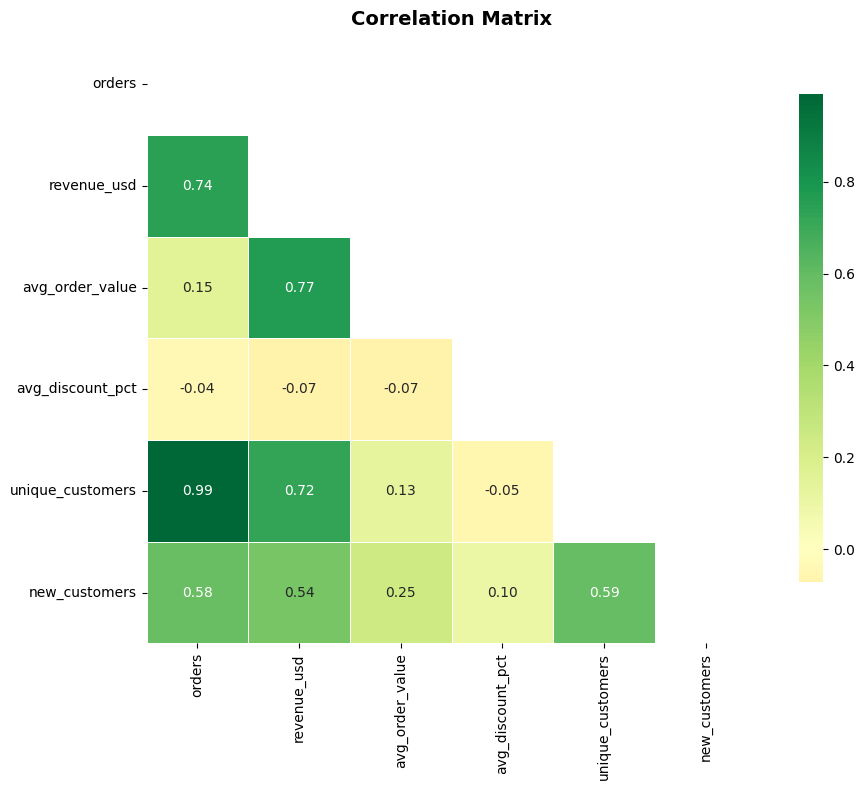

In [38]:
# Correlation matrix
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

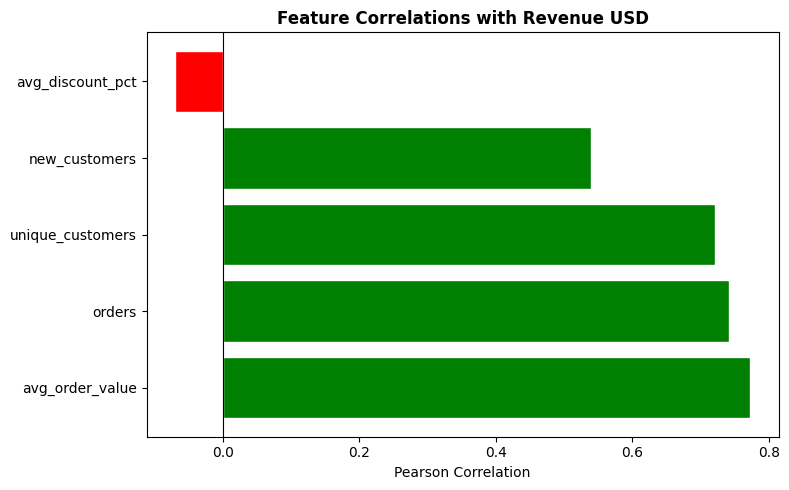

In [39]:
# Top correlations with revenue_usd
target_corr = (
    corr["revenue_usd"]
    .drop("revenue_usd")
    .sort_values(key=abs, ascending=False)
    .reset_index()
)
target_corr.columns = ["Feature", "Correlation with revenue_usd"]

colors = target_corr["Correlation with revenue_usd"].apply(
    lambda x: "green" if x > 0 else "red"
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    target_corr["Feature"],
    target_corr["Correlation with revenue_usd"],
    color=colors, edgecolor="white"
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlations with Revenue USD", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

In [40]:
# Revenue over time
fig = px.line(
    df, x="month", y="revenue_usd",
    title="Revenue Over Time",
    markers=True, template="plotly_white"
)
fig.update_traces(line_color="steelblue", marker_size=5)
fig.update_layout(
    xaxis_title="Year", yaxis_title="Revenue (USD)",
    hovermode="x unified"
)
fig.show()

In [41]:
# growth rate for revenue
df["revenue_mom_growth"] = df["revenue_usd"].pct_change() * 100

fig = px.bar(
    df, x="month", y="revenue_mom_growth",
    title="Revenue Growth over time (%)",
    color="revenue_mom_growth",
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
    template="plotly_white"
)
fig.update_layout(xaxis_title="Year", yaxis_title="MoM Growth (%)")
fig.show()

In [42]:
# Rolling 3-month average
df["revenue_rolling3"] = df["revenue_usd"].rolling(window=3).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df["month"], y=df["revenue_usd"],
    name="Actual", mode="lines+markers",
    line=dict(color="steelblue", width=1.5), marker_size=4
))
fig.add_trace(go.Scatter(
    x=df["month"], y=df["revenue_rolling3"],
    name="3-Month Rolling Avg", mode="lines",
    line=dict(color="orange", width=2.5, dash="dash")
))
fig.update_layout(
    title="Revenue: Actual vs 3-Month Rolling Average",
    template="plotly_white", hovermode="x unified",
    xaxis_title="Year", yaxis_title="Revenue (USD)"
)
fig.show()

### 6. Feature Selection

In [43]:
df_features = df.copy().sort_values('month').reset_index(drop=True)

# Calendar features
df_features['month_num'] = df_features['month'].dt.month
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month_num'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month_num'] / 12)

# Lag features (past revenue signal)
for lag in [1, 2, 3, 6, 12]:
    df_features[f"revenue_lag_{lag}"] = df_features['revenue_usd'].shift(lag)

# Rolling statistics (trend smoothing)
df_features["revenue_roll3_mean"] = df_features['revenue_usd'].shift(1).rolling(3).mean()
df_features["revenue_roll6_mean"] = df_features['revenue_usd'].shift(1).rolling(6).mean()
df_features["revenue_roll3_std"]  = df_features['revenue_usd'].shift(1).rolling(3).std()

# month-over-month and year-over-year growth rate
df_features["revenue_mom_growth"] = df_features['revenue_usd'].pct_change(1)
df_features["revenue_yoy_growth"] = df_features['revenue_usd'].pct_change(12)

# Business feature lags (avoid data leakage)
business_cols = [
    "orders", "avg_order_value", "avg_discount_pct", "unique_customers", "new_customers"
]
for col in business_cols:
    if col in df_features.columns:
        df_features[f"{col}_lag1"] = df_features[col].shift(1)  # lag by 1 to prevent leakage

print(f"\nNew features added:\n{[c for c in df_features.columns if c not in df.columns]}")


New features added:
['month_num', 'month_sin', 'month_cos', 'revenue_lag_1', 'revenue_lag_2', 'revenue_lag_3', 'revenue_lag_6', 'revenue_lag_12', 'revenue_roll3_mean', 'revenue_roll6_mean', 'revenue_roll3_std', 'revenue_yoy_growth', 'orders_lag1', 'avg_order_value_lag1', 'avg_discount_pct_lag1', 'unique_customers_lag1', 'new_customers_lag1']


### 7. Model Building

In [44]:
# defining some constants
TARGET = 'revenue_usd'
DATE_COL = 'month'
TEST_MONTHS = 12

split_idx = len(df) - TEST_MONTHS

df_train = df_features.iloc[:split_idx].copy()
df_test  = df_features.iloc[split_idx:].copy()
df_train.head()

print(f"Train: {df_train[DATE_COL].min().date()} → {df_train[DATE_COL].max().date()}  ({len(df_train)} months)")
print(f"Test:  {df_test[DATE_COL].min().date()}  → {df_test[DATE_COL].max().date()}   ({len(df_test)} months)")

Train: 2020-01-01 → 2024-12-01  (57 months)
Test:  2025-01-01  → 2026-03-01   (12 months)


In [45]:
# Prepare Prophet format
prophet_train = df_train[[DATE_COL, TARGET]].rename(
    columns={DATE_COL: "ds", TARGET: "y"}
)
prophet_test = df_test[[DATE_COL, TARGET]].rename(
    columns={DATE_COL: "ds", TARGET: "y"}
)

# Fit Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

# Forecast on train + test
prophet_all = pd.concat([prophet_train, prophet_test]).reset_index(drop=True)
prophet_forecast = prophet_model.predict(prophet_all[["ds"]])

# Extract predictions
df_train["prophet_yhat"] = prophet_forecast["yhat"].iloc[:len(df_train)].values
df_test["prophet_yhat"]  = prophet_forecast["yhat"].iloc[len(df_train):].values

# Compute residuals (what Prophet couldn't explain)
df_train["prophet_residual"] = df_train[TARGET] - df_train["prophet_yhat"]
df_test["prophet_residual"]  = df_test[TARGET]  - df_test["prophet_yhat"]

print(f"\nProphet train residual stats:")
print(df_train["prophet_residual"].describe().round(2))


Prophet train residual stats:
count      57.00
mean        0.08
std      2284.26
min     -4604.19
25%     -1368.83
50%       349.06
75%      1298.91
max      4751.21
Name: prophet_residual, dtype: float64


In [46]:
# Define XGBoost features
xgb_features = [
    # Calendar
    "month_num", "quarter", "month_sin", "month_cos",
    # Revenue lags
    "revenue_lag_1", "revenue_lag_2", "revenue_lag_3",
    "revenue_lag_6", "revenue_lag_12",
    # Rolling stats
    "revenue_roll3_mean", "revenue_roll6_mean", "revenue_roll3_std",
    # Growth rates
    "revenue_mom_growth", "revenue_yoy_growth",
    # Prophet signal
    "prophet_yhat",
    # Business feature lags (use lag1 to prevent leakage)
    "orders_lag1", "avg_order_value_lag1",
    "avg_discount_pct_lag1",
    "unique_customers_lag1", "new_customers_lag1"
]

# Keep only available columns
xgb_features = [f for f in xgb_features if f in df_train.columns]
print(f"XGBoost features ({len(xgb_features)}): {xgb_features}")

X_train = df_train[xgb_features]
y_train_resid = df_train["prophet_residual"]  # train on residuals

X_test  = df_test[xgb_features]
y_test  = df_test[TARGET]

# Fit XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train_resid,
    eval_set=[(X_train, y_train_resid)],
    verbose=False
)

# ── 5c. Predict residuals ─────────────────────────────────────────────────────
df_train["xgb_residual_pred"] = xgb_model.predict(X_train)
df_test["xgb_residual_pred"]  = xgb_model.predict(X_test)

# ── 5d. Final hybrid forecast = Prophet + XGBoost correction ──────────────────
df_train["hybrid_forecast"] = df_train["prophet_yhat"] + df_train["xgb_residual_pred"]
df_test["hybrid_forecast"]  = df_test["prophet_yhat"]  + df_test["xgb_residual_pred"]

XGBoost features (20): ['month_num', 'quarter', 'month_sin', 'month_cos', 'revenue_lag_1', 'revenue_lag_2', 'revenue_lag_3', 'revenue_lag_6', 'revenue_lag_12', 'revenue_roll3_mean', 'revenue_roll6_mean', 'revenue_roll3_std', 'revenue_mom_growth', 'revenue_yoy_growth', 'prophet_yhat', 'orders_lag1', 'avg_order_value_lag1', 'avg_discount_pct_lag1', 'unique_customers_lag1', 'new_customers_lag1']


In [47]:
def evaluate(y_true, y_pred, label="Model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    print(f"  MAE:   ${mae:,.0f}")
    print(f"  RMSE:  ${rmse:,.0f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  R²:    {r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

# Compare all three on test set
results_prophet = evaluate(df_test[TARGET], df_test["prophet_yhat"],        "Prophet only")
results_hybrid  = evaluate(df_test[TARGET], df_test["hybrid_forecast"],     "Prophet + XGBoost hybrid")


  Prophet only
  MAE:   $3,133
  RMSE:  $4,005
  MAPE:  8.75%
  R²:    0.0091

  Prophet + XGBoost hybrid
  MAE:   $2,220
  RMSE:  $2,773
  MAPE:  6.27%
  R²:    0.5252


### 8. Forecast revenue

In [48]:
FORECAST_MONTHS = 12

# Future date range
last_date    = df_features[DATE_COL].max()
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS,
    freq="MS"
)

# Prophet forecast
prophet_future    = pd.DataFrame({"ds": future_dates})
prophet_future_fc = prophet_model.predict(prophet_future)

future_df = pd.DataFrame({
    DATE_COL:       future_dates,
    "prophet_yhat": prophet_future_fc["yhat"].values,
})

# Calendar features
future_df["month_num"] = future_df[DATE_COL].dt.month
future_df["quarter"]   = future_df[DATE_COL].dt.quarter
future_df["year"]      = future_df[DATE_COL].dt.year
future_df["month_sin"] = np.sin(2 * np.pi * future_df["month_num"] / 12)
future_df["month_cos"] = np.cos(2 * np.pi * future_df["month_num"] / 12)

# Iterative lag propagation
# Build extended revenue series — actuals + placeholders for future
revenue_series = pd.Series(
    df_features[TARGET].tolist() + [np.nan] * FORECAST_MONTHS
)

for i in range(FORECAST_MONTHS):
    idx = len(df_features) + i

    # Lag features
    for lag in [1, 2, 3, 6, 12]:
        future_df.loc[i, f"revenue_lag_{lag}"] = (
            revenue_series.iloc[idx - lag] if idx - lag >= 0
            else df_features[TARGET].iloc[0]
        )

    # Rolling stats
    past_vals = revenue_series.iloc[max(0, idx-6):idx].dropna()
    future_df.loc[i, "revenue_roll3_mean"] = past_vals.tail(3).mean()
    future_df.loc[i, "revenue_roll6_mean"] = past_vals.tail(6).mean()
    future_df.loc[i, "revenue_roll3_std"]  = past_vals.tail(3).std()

    # Growth rates
    future_df.loc[i, "revenue_mom_growth"] = (
        revenue_series.iloc[idx-1] / revenue_series.iloc[idx-2] - 1
        if idx >= 2 and not pd.isna(revenue_series.iloc[idx-2]) else 0
    )
    future_df.loc[i, "revenue_yoy_growth"] = (
        revenue_series.iloc[idx-1] / revenue_series.iloc[idx-13] - 1
        if idx >= 13 and not pd.isna(revenue_series.iloc[idx-13]) else 0
    )

    # Business feature lags — forward-fill last known values
    for col in ["orders_lag1", "avg_order_value_lag1", "avg_discount_pct_lag1",
                "return_rate_lag1", "unique_customers_lag1", "new_customers_lag1"]:
        if col in df_features.columns:
            future_df.loc[i, col] = df_features[col].iloc[-1]

    # Predict this month and feed into next month's lags
    xgb_pred_i = xgb_model.predict(future_df.loc[[i], xgb_features])[0]
    revenue_series.iloc[idx] = future_df.loc[i, "prophet_yhat"] + xgb_pred_i

# Final hybrid forecast
future_df["xgb_residual_pred"] = xgb_model.predict(future_df[xgb_features])
future_df["hybrid_forecast"]   = future_df["prophet_yhat"] + future_df["xgb_residual_pred"]
future_df["hybrid_forecast"]   = future_df["hybrid_forecast"].clip(lower=0)

In [49]:
# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_features[DATE_COL], y=df_features[TARGET],
    name="Historical actual",
    mode="lines+markers",
    line=dict(color="steelblue", width=2),
    marker=dict(size=4)
))
fig.add_trace(go.Scatter(
    x=df_test[DATE_COL], y=df_test["hybrid_forecast"],
    name="Hybrid forecast (test validation)",
    mode="lines+markers",
    line=dict(color="#7F77DD", width=2, dash="dot"),
    marker=dict(size=5)
))
fig.add_trace(go.Scatter(
    x=future_df[DATE_COL], y=future_df["hybrid_forecast"],
    name="12-month forecast",
    mode="lines+markers",
    line=dict(color="#1D9E75", width=2.5),
    marker=dict(size=7, symbol="diamond")
))
fig.update_layout(
    title="12-Month Revenue Forecast",
    xaxis_title="Month", yaxis_title="Revenue (USD)",
    template="plotly_white", hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.show()